# Algorithms for improving the b-chromatic colouring

## Packages

In [56]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt
from b_chromatic_utils import *
from b_chromatic_colouring import get_m_degree, get_dense_vertices
import pandas as pd

## Helpers functions

In [2]:
def is_proper(G, c):
    for u,v in G.edges():
        if((c[u] is not None and c[v] is not None) and (c[u] == c[v])):
            return False
    return True

In [10]:
def get_b_chromatic_vertices(G, c):
    C = set(list(c.values()))
    b_chr_list = []
    for u in G.nodes():
        cNu = {c[v] for v in G.adj[u]}
        if len(cNu) == len(C)-1: b_chr_list.append(u)
    return b_chr_list


## Partition redistribution algorithm (heuristic)

In [113]:
def partition_redistribution(G, f):
    
    #node_degree_colour = {f[u]:G.degree(u) for u in G.nodes()}
    #print(node_degree_colour)
    #C = set(dict(sorted(node_degree_colour.items(), key = lambda x:x[1])).keys())
    
    C = set(list(f.values()))
    print("Original set of colours: {}".format(C))
    fp = f.copy()
    Cp = C.copy()
    for c in C:
        Vc = {u for u in G.nodes() if fp[u] == c}
        Vcp = Vc.copy()
        for v in Vc:
            cNv = {fp[u] for u in G.adj[v]}
            if len(cNv) < len(Cp)-1:
                colours_diff = Cp.difference(cNv.union(set([c])))
                assert colours_diff != set()
                cp = list(colours_diff)[0]
                fp[v] = cp
                Vcp.remove(v)
        if Vcp == set():
            Cp.remove(c)
    print("New set of colours: {}".format(Cp))
    return fp

### Testing on a small graph 1

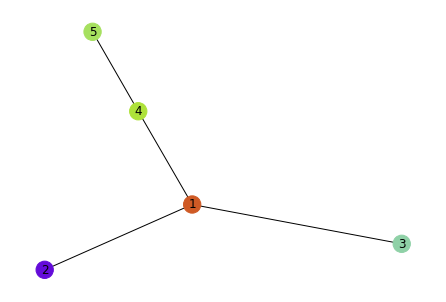

In [4]:
G = nx.Graph()
G.add_edges_from([(1,2), (1,3), (1,4), (4,5)])
f = {}
for i, u in enumerate(G.nodes()):
    f[u] = i+1
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

### Testing on a random graph

Number of colours: 15


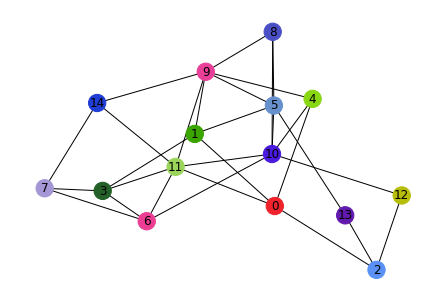

In [48]:
G = nx.random_graphs.gnp_random_graph(15, 0.3)
f = {u:i+1 for i, u in enumerate(G.nodes())}
print("Number of colours: {}".format(len(set(list(f.values())))))
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [49]:
fp = partition_redistribution(G, f)
assert is_proper(G, fp)
print("Number of colours: {}".format(len(set(list(fp.values())))))

{12, 13, 14, 15}
Number of colours: 4


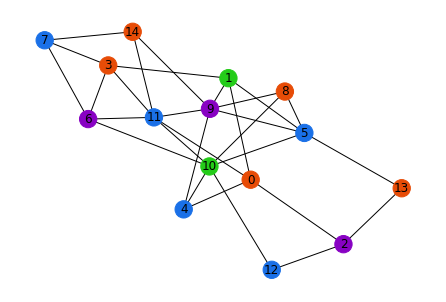

In [55]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(fp))

In [51]:
Vp = get_b_chromatic_vertices(G, f)
C = set(f.values())
Vp, C

([0, 1, 3, 4, 5, 6, 8, 9, 10, 11], {12, 13, 14, 15})

We compare the number of colours used and the m-degree of $G$

In [52]:
len(C), get_m_degree(G)

(4, 5)

### Testing on a small graph 2

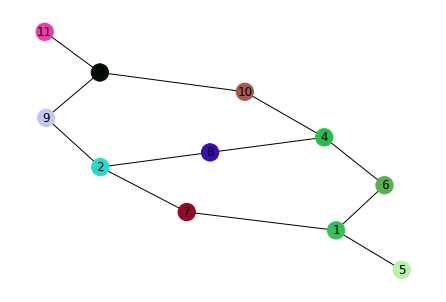

In [114]:
G = nx.Graph()
G.add_edges_from([(1,5), (1,6), (1,7), (2,7), (2,8), (2,9), (3,9), (3,10), (3,11), (4,6), (4,8), (4,10)])
f = {u:u for u in G.nodes()}
nx.draw(G, with_labels=True, node_color=get_colors_to_use(f))

In [115]:
m = get_m_degree(G)
fp = partition_redistribution(G, f)
assert is_proper(G, fp)
print("Number of colours: {}".format(len(set(list(fp.values())))))
print("m(G) = {}".format(m))
print("b-chromatic vertices: {}".format(get_b_chromatic_vertices(G, fp)))
print("Dense vertices: {}".format(get_dense_vertices(G, get_m_degree(G))))

Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
New set of colours: {8, 10, 11}
Number of colours: 3
m(G) = 4
b-chromatic vertices: [1, 6, 7, 2, 8, 9, 3, 4]
Dense vertices: [1, 2, 3, 4]


### Testing on a bunch of random graph with given number of vertices

In [123]:
df_res = {  "n":[], 
            "#colours_used":[], 
            "m_degree_G":[],
            "#dense_vertices":[],
            "#b_chromatic_vertices":[],
            "#dense_non_b_chro":[],
            "#dense_b_chro":[],
            "#non_dense_b_chro":[]}
k = 1
for n in range(50, 1050, 50):
    colours_used_avg = 0
    m_avg = 0
    n_dense_avg = 0
    b_chro_avg = 0
    n_dense_non_b_chro = 0
    n_dense_b_chro = 0
    n_non_dense_b_chro = 0
    for i in range(k):
        Gi = nx.random_graphs.gnp_random_graph(n, 0.50)
        mi = get_m_degree(Gi)
        Vpi = get_dense_vertices(Gi, mi)
        fi = {u:j+1 for j, u in enumerate(Gi.nodes())}
        fpi = partition_redistribution(Gi, fi)
        assert is_proper(Gi, fpi)
        V_b_chro = get_b_chromatic_vertices(Gi, fpi)
        Ci = set(fpi.values())
        colours_used_avg += len(Ci)
        m_avg += mi
        n_dense_avg += len(Vpi)
        b_chro_avg += len(V_b_chro)
        n_dense_non_b_chro += len(set(Vpi).difference(set(V_b_chro)))
        n_dense_b_chro += len(set(Vpi).intersection(set(V_b_chro)))
        n_non_dense_b_chro += len(set(V_b_chro).difference(set(Vpi)))
    df_res["n"].append(n)
    df_res["#colours_used"].append(colours_used_avg/k)
    df_res["m_degree_G"].append(m_avg/k)
    df_res["#dense_vertices"].append(n_dense_avg/k)
    df_res["#b_chromatic_vertices"].append(b_chro_avg/k)
    df_res["#dense_non_b_chro"].append(n_dense_non_b_chro)
    df_res["#dense_b_chro"].append(n_dense_b_chro)
    df_res["#non_dense_b_chro"].append(n_non_dense_b_chro)


Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50}
New set of colours: {35, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50}
Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100}
New set of colours: {77, 78, 81, 82, 83, 84, 86, 87, 89, 90, 91, 92, 93, 95, 96, 97, 98, 99, 100}
Original set of colours: {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 4

In [124]:
df_res = pd.DataFrame(df_res)

In [125]:
df_res

,n,#colours_used,m_degree_G,#dense_vertices,#b_chromatic_vertices,#dense_non_b_chro,#dense_b_chro,#non_dense_b_chro
0,50,14.0,26.0,27.0,20.0,10,17,3
1,100,19.0,50.0,54.0,57.0,18,36,21
2,150,29.0,76.0,83.0,66.0,34,49,17
3,200,33.0,102.0,103.0,142.0,19,84,58
4,250,41.0,126.0,135.0,111.0,61,74,37
5,300,46.0,150.0,162.0,191.0,40,122,69
6,350,54.0,175.0,185.0,158.0,82,103,55
7,400,59.0,200.0,206.0,214.0,89,117,97
8,450,67.0,226.0,226.0,205.0,104,122,83
9,500,73.0,251.0,269.0,207.0,138,131,76
